In [2]:
import cv2
from matplotlib import pyplot as plt
from pathlib import Path

import src.ModelTrain as ModelTrain

In [3]:
F1_FIG_NAME = 'f1_score_evolution.png'
LOSS_FIG_NAME = 'loss_evolution.png'
CONF_MATRIX_NAME = 'confusion_matrix.png'

In [4]:
baseline_img_dir = Path('unified_images')
baseline_csv_dir = Path('unified_data_baseline.csv')
results_dir = Path('baseline_experiment')

trained_model, validation_loader = ModelTrain.train(baseline_csv_dir, baseline_img_dir, results_dir)

Hardware assigned for tensor computations: cuda
Initiating Baseline Training Phase. Saving results to: C:\Users\luis\Documents\TFG - Data-Centric AI\results\baseline_experiment


Training Progress: 100%|██████████| 100/100 [1:04:51<00:00, 38.92s/epoch, Train Loss=0.5874, Val Loss=1.2528, Val F1=0.4261]          



Optimization sequence completed. Optimal Validation F1-Score: 0.4659
Artifacts successfully written to 'C:\Users\luis\Documents\TFG - Data-Centric AI\results\baseline_experiment'.


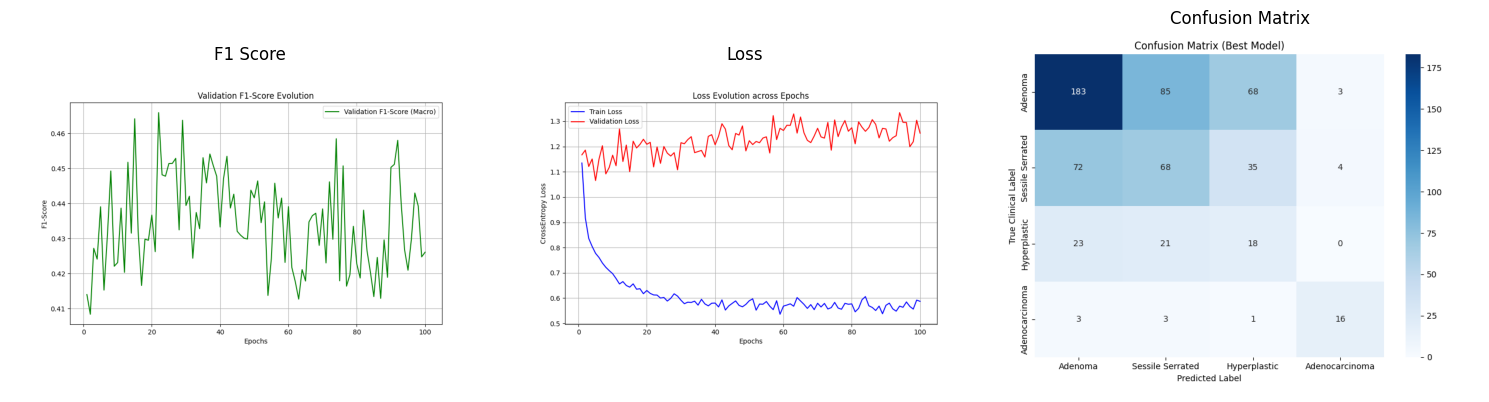

In [5]:
results_path = ModelTrain.RESULTS_DIR / Path(results_dir)
image_paths = [results_path / F1_FIG_NAME, results_path / LOSS_FIG_NAME, results_path / CONF_MATRIX_NAME]

titles = ["F1 Score", "Loss", "Confusion Matrix"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, img_path, title in zip(axes, image_paths, titles):
    # Carga de la imagen
    img = cv2.imread(str(img_path))
    
    if img is not None:
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img_rgb)
    else:
        ax.text(0.5, 0.5, 'Error: Image not found', fontsize=12, color='red',ha='center', va='center', transform=ax.transAxes)
        
    ax.set_title(title, fontsize=12)
    ax.axis('off') 

plt.tight_layout()
plt.show()